# Loading the Dataset and Data Preparation

In [18]:
# Libraries (only what's necessary)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [19]:

# Load

df = pd.read_csv('cargo_fright.csv')
df.columns = [c.strip() for c in df.columns]
df = df.loc[:, ~df.columns.duplicated()]

# Identify numeric-like columns (durations, ids, counts)
import re
def looks_duration(col): return bool(re.search(r'(rcs|dep|rcf|dlv)_(?:\d_)?[pe]$', col))
def looks_id_or_count(col): return bool(re.search(r'(legid|place|hops|legs|nr)$', col))

dur_cols = [c for c in df.columns if looks_duration(c)]
count_cols = [c for c in df.columns if looks_id_or_count(c) and c not in dur_cols]

# Convert to numeric
for c in dur_cols + count_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Basic NA report
na_report = df[dur_cols + count_cols].isna().mean().sort_values(ascending=False)
print("Top missing columns (ratio):\n", na_report.head(12))

# Handle NA for durations: treat missing segments as 0 minutes (segment absent)
df[dur_cols] = df[dur_cols].fillna(0)

# For counters/ids we can leave NaN (ids may be masked); 'hops' benefit from 0
hop_cols = [c for c in df.columns if c.endswith("_hops")]
if hop_cols:
    df[hop_cols] = df[hop_cols].fillna(0)


Top missing columns (ratio):
 i3_dep_3_p        0.997971
i3_dep_3_e        0.997971
i3_rcf_3_p        0.997971
i3_rcf_3_e        0.997971
i3_rcf_3_place    0.997971
i3_dep_3_place    0.997971
i2_dep_3_p        0.996449
i2_dep_3_place    0.996449
i2_rcf_3_place    0.996449
i2_rcf_3_e        0.996449
i2_dep_3_e        0.996449
i2_rcf_3_p        0.996449
dtype: float64


In [20]:

# Feature engineering: totals across legs/milestones
MILESTONES = ["rcs", "dep_1", "rcf_1", "dep_2", "rcf_2", "dep_3", "rcf_3", "dlv"]
LEGS_PREFIXES = ["i1", "i2", "i3", "o"]

def collect_cols(prefixes, milestones, suffix):
    cols = []
    for p in prefixes:
        for m in milestones:
            col = f"{p}_{m}_{suffix}"
            if col in df.columns:
                cols.append(col)
    return cols

planned_cols = collect_cols(LEGS_PREFIXES, MILESTONES, "p")
effective_cols = collect_cols(LEGS_PREFIXES, MILESTONES, "e")

df["total_planned"]   = df[planned_cols].sum(axis=1)
df["total_effective"] = df[effective_cols].sum(axis=1)
df["total_gap"]       = df["total_effective"] - df["total_planned"]

# Delivery-only features (requested)
dlv_p_cols = [c for c in planned_cols   if c.endswith("dlv_p")]
dlv_e_cols = [c for c in effective_cols if c.endswith("dlv_e")]
df["delivery_planned"]   = df[dlv_p_cols].sum(axis=1) if dlv_p_cols else 0
df["delivery_effective"] = df[dlv_e_cols].sum(axis=1) if dlv_e_cols else 0
df["delivery_delay"]     = df["delivery_effective"] - df["delivery_planned"]

# Hops and legs
df["total_hops"] = df[hop_cols].sum(axis=1) if hop_cols else 0
if "legs" not in df.columns:
    # infer from presence of dep_1 planned segments
    infer_cols = [c for c in ["i1_dep_1_p","i2_dep_1_p","i3_dep_1_p"] if c in df.columns]
    if infer_cols:
        df["legs"] = df[infer_cols].gt(0).sum(axis=1)
    else:
        df["legs"] = 0

# Filter to valid journeys
df_model = df[(df['total_planned']>0) & (df['total_effective']>0)].copy()

print("Rows:", len(df), "→ after filtering:", len(df_model))
print("\nQuick stats (totals):\n", df_model[["total_planned","total_effective","total_gap","delivery_planned","delivery_effective","delivery_delay","total_hops","legs"]].describe())


Rows: 3942 → after filtering: 3942

Quick stats (totals):
        total_planned  total_effective      total_gap  delivery_planned  \
count    3942.000000      3942.000000    3942.000000       3942.000000   
mean    23310.858955     20100.739472   -3210.119482      10939.988584   
std     11415.613793     22015.471293   19480.353607       4747.693615   
min      3679.000000       915.000000  -27823.000000        605.000000   
25%     15422.250000      9679.000000  -10242.000000       7562.500000   
50%     21288.500000     15275.500000   -6101.000000      10920.000000   
75%     28052.500000     24484.750000    -644.250000      14550.000000   
max    114521.000000    574894.000000  555259.000000      33330.000000   

       delivery_effective  delivery_delay   total_hops         legs  
count         3942.000000     3942.000000  3942.000000  3942.000000  
mean          8335.809488    -2604.179097     4.101218     2.012177  
std          19193.493199    19406.460616     1.501637     0.825

C:\Users\amitd\AppData\Local\Temp\ipykernel_31452\770291394.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["total_gap"]       = df["total_effective"] - df["total_planned"]
C:\Users\amitd\AppData\Local\Temp\ipykernel_31452\770291394.py:24: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["delivery_planned"]   = df[dlv_p_cols].sum(axis=1) if dlv_p_cols else 0
C:\Users\amitd\AppData\Local\Temp\ipykernel_31452\770291394.py:25: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.

# Outliers — IQR Detection and Transformation (Winsorization)

In [21]:
def iqr_caps(s, k=1.5):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k*iqr
    upper = q3 + k*iqr
    return lower, upper

key_vars = ["total_planned","total_effective","total_gap","delivery_planned","delivery_effective","delivery_delay"]
pre_counts = {}
bounds = {}
for v in key_vars:
    lo, hi = iqr_caps(df_model[v])
    bounds[v] = (lo, hi)
    pre_counts[v] = ((df_model[v] < lo) | (df_model[v] > hi)).sum()

print("Outliers by IQR (k=1.5):")
for v in key_vars:
    lo, hi = bounds[v]
    print(f"{v:20s}  outliers={pre_counts[v]:4d}  lower={lo:,.2f}  upper={hi:,.2f}")

# Winsorize (cap to IQR bounds)
df_iqr = df_model.copy()
for v in key_vars:
    lo, hi = bounds[v]
    df_iqr[v] = df_iqr[v].clip(lower=lo, upper=hi)

print("\nPost-IQR capping stats:")
print(df_iqr[key_vars].describe())


Outliers by IQR (k=1.5):
total_planned         outliers= 181  lower=-3,523.12  upper=46,997.88
total_effective       outliers= 232  lower=-12,529.62  upper=46,693.38
total_gap             outliers= 234  lower=-24,638.62  upper=13,752.38
delivery_planned      outliers=  14  lower=-2,918.75  upper=25,031.25
delivery_effective    outliers= 382  lower=-7,947.12  upper=18,795.88
delivery_delay        outliers= 237  lower=-23,688.62  upper=13,926.38

Post-IQR capping stats:
       total_planned  total_effective     total_gap  delivery_planned  \
count     3942.00000      3942.000000   3942.000000       3942.000000   
mean     22756.55971     18591.981989  -4688.750190      10931.647007   
std       9571.54026     11933.380547   7868.678581       4718.419942   
min       3679.00000       915.000000 -24638.625000        605.000000   
25%      15422.25000      9679.000000 -10242.000000       7562.500000   
50%      21288.50000     15275.500000  -6101.000000      10920.000000   
75%      28052.5

## Visual Check — Before vs After (Boxplot)

C:\Users\amitd\AppData\Local\Temp\ipykernel_31452\3640015207.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_model["delivery_effective"].dropna(),


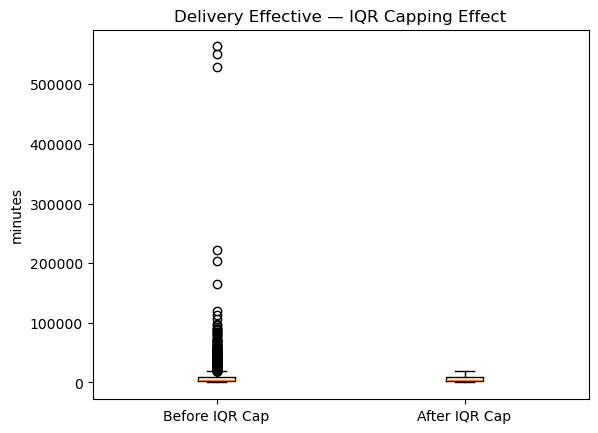

In [22]:
# Boxplot for delivery_effective (before/after) as an example
plt.figure()
plt.boxplot([df_model["delivery_effective"].dropna(),
             df_iqr["delivery_effective"].dropna()],
            labels=["Before IQR Cap","After IQR Cap"])
plt.title("Delivery Effective — IQR Capping Effect")
plt.ylabel("minutes")
plt.show()

# Outliers — Z-Score Test

In [23]:
from scipy.stats import zscore

z_df = df_model[key_vars].apply(zscore, nan_policy='omit')
z_outliers = (z_df.abs() > 3).sum()  # count per variable using |z|>3
print("Z-score outliers count (|z|>3):")
print(z_outliers)

# Keep a version with optional removal by z-score (not default — we only flag here)
df_zflag = df_model.copy()
for v in key_vars:
    df_zflag[f"{v}_z"] = z_df[v]


Z-score outliers count (|z|>3):
total_planned         80
total_effective       33
total_gap             31
delivery_planned      14
delivery_effective    34
delivery_delay        32
dtype: int64


# Univariate and Two-Variable Exploration

## Distribution of Total Effective Duration

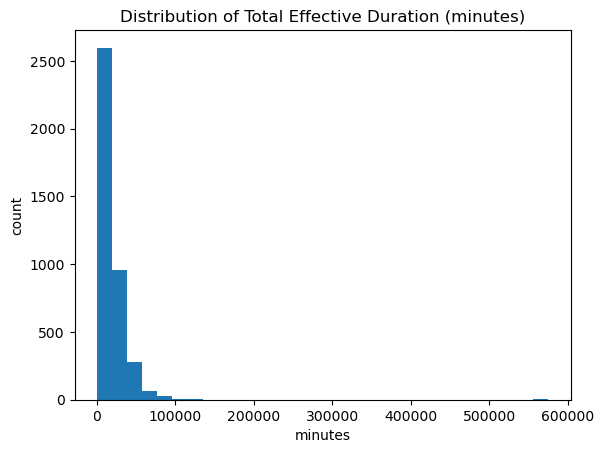

In [24]:
plt.figure()
df_model["total_effective"].plot(kind="hist", bins=30)
plt.title("Distribution of Total Effective Duration (minutes)")
plt.xlabel("minutes"); plt.ylabel("count"); plt.show()

## Planned vs Effective (Scatter)

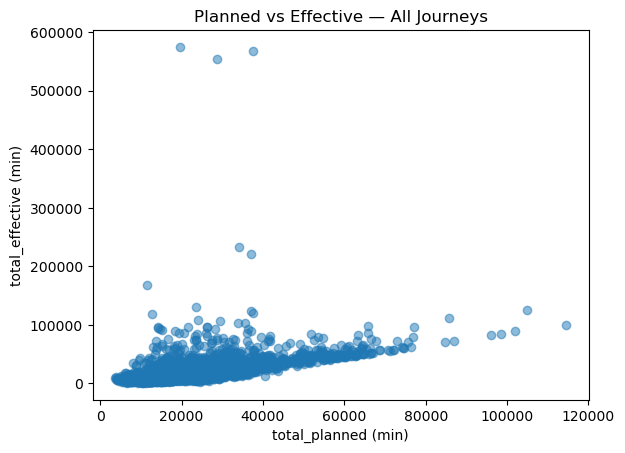


Correlation matrix:
                     total_planned  total_effective  total_gap  \
total_planned            1.000000         0.468552  -0.056479   
total_effective          0.468552         1.000000   0.855563   
total_gap               -0.056479         0.855563   1.000000   
delivery_effective       0.079516         0.897014   0.967152   
delivery_delay          -0.047720         0.858778   0.998502   

                    delivery_effective  delivery_delay  
total_planned                 0.079516       -0.047720  
total_effective               0.897014        0.858778  
total_gap                     0.967152        0.998502  
delivery_effective            1.000000        0.969803  
delivery_delay                0.969803        1.000000  


In [25]:
plt.figure()
plt.scatter(df_model["total_planned"], df_model["total_effective"], alpha=0.5)
plt.title("Planned vs Effective — All Journeys")
plt.xlabel("total_planned (min)"); plt.ylabel("total_effective (min)"); plt.show()

print("\nCorrelation matrix:\n", df_model[["total_planned","total_effective","total_gap","delivery_effective","delivery_delay"]].corr())

## Categorical — By Legs

C:\Users\amitd\AppData\Local\Temp\ipykernel_31452\2390183008.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=sorted(df_model['legs'].unique()))


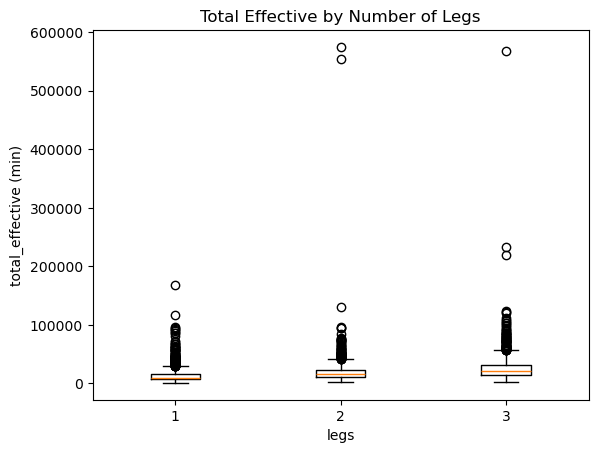

In [26]:
plt.figure()
groups = [df_model.loc[df_model['legs']==k, 'total_effective'].dropna().values for k in sorted(df_model['legs'].unique())]
plt.boxplot(groups, labels=sorted(df_model['legs'].unique()))
plt.title("Total Effective by Number of Legs"); plt.xlabel("legs"); plt.ylabel("total_effective (min)"); plt.show()

# Linear Regression

## Default Algorithm

Linear Regression — RMSE: 5,331.34  MAE: 4,243.71  R2: 0.092


c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


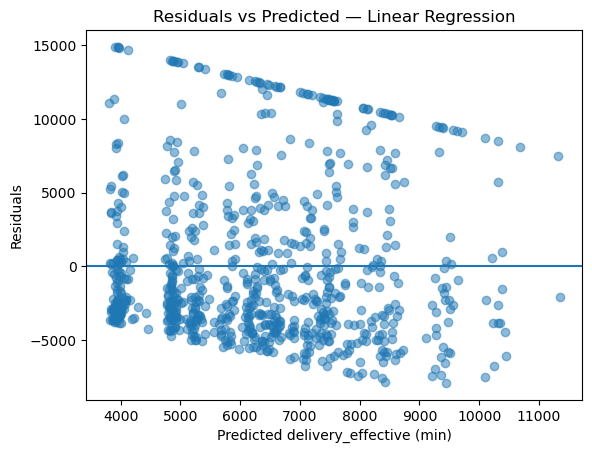

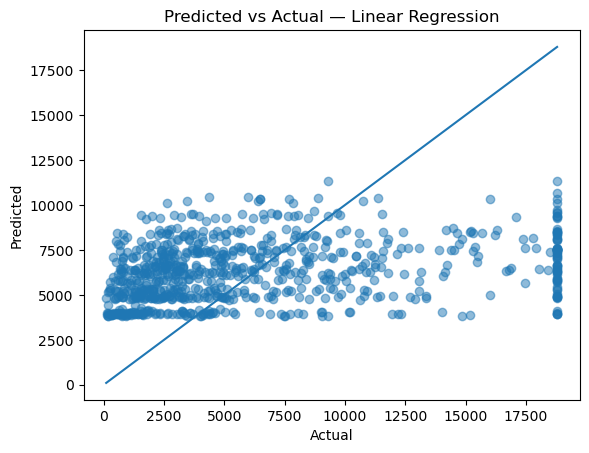

Linear Regression Equation:
delivery_effective = 5458.18 + 141.38*total_planned + 1364.69*total_hops + -154.78*delivery_planned + 437.29*legs


In [27]:
# Use the IQR-capped dataframe for modeling
FEATURES = ["total_planned","legs","total_hops","delivery_planned"]
TARGET = "delivery_effective"  # focus on delivery prediction; we also report total later

X = df_iqr[FEATURES].copy()
y = df_iqr[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = ["total_planned","total_hops","delivery_planned"]
passthrough_features = ["legs"]
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("passthrough", "passthrough", passthrough_features),
])

linreg = Pipeline([("prep", preprocess), ("model", LinearRegression())])
linreg.fit(X_train, y_train)
pred_lin = linreg.predict(X_test)

rmse = mean_squared_error(y_test, pred_lin, squared=False)
mae  = mean_absolute_error(y_test, pred_lin)
r2   = r2_score(y_test, pred_lin)
print(f"Linear Regression — RMSE: {rmse:,.2f}  MAE: {mae:,.2f}  R2: {r2:.3f}")

# Residuals
plt.figure()
plt.scatter(pred_lin, y_test - pred_lin, alpha=0.5)
plt.axhline(0)
plt.title("Residuals vs Predicted — Linear Regression")
plt.xlabel("Predicted delivery_effective (min)"); plt.ylabel("Residuals"); plt.show()

# Predicted vs Actual
plt.figure()
plt.scatter(y_test, pred_lin, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual — Linear Regression")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.show()


#linear equation printout with coefficients and  intercept
coefficients = linreg.named_steps['model'].coef_
intercept = linreg.named_steps['model'].intercept_
feature_names = numeric_features + passthrough_features
equation = f"delivery_effective = {intercept:.2f} + " +" + ".join([f"{coef:.2f}*{name}" for coef, name in zip(coefficients, feature_names)])
print("Linear Regression Equation:")
print(equation)

## Effect of Log-Transform

In [28]:
linreg_log = Pipeline([("prep", preprocess), ("model", LinearRegression())])
linreg_log_ttr = TransformedTargetRegressor(regressor=linreg_log, func=np.log1p, inverse_func=np.expm1)

linreg_log_ttr.fit(X_train, y_train)
pred_ll = linreg_log_ttr.predict(X_test)

rmse = mean_squared_error(y_test, pred_ll, squared=False)
mae  = mean_absolute_error(y_test, pred_ll)
r2   = r2_score(y_test, pred_ll)
print(f"Linear Regression (log1p target) — RMSE: {rmse:,.2f}  MAE: {mae:,.2f}  R2: {r2:.3f}")


Linear Regression (log1p target) — RMSE: 5,712.14  MAE: 3,949.63  R2: -0.043


c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Random Forest Regressor

## Default Algorithm

Random Forest — RMSE: 5,747.59  MAE: 4,488.96  R2: -0.056)


c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


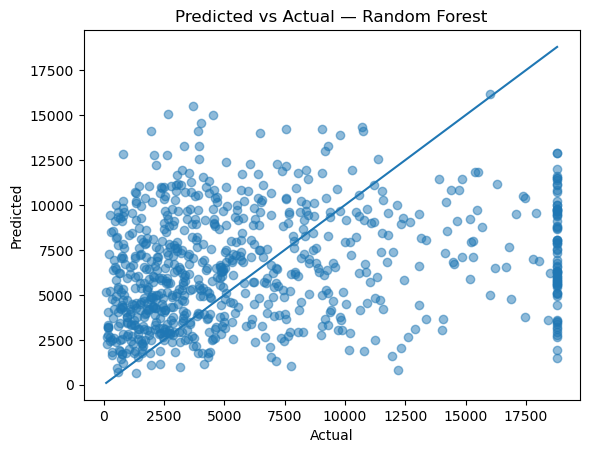

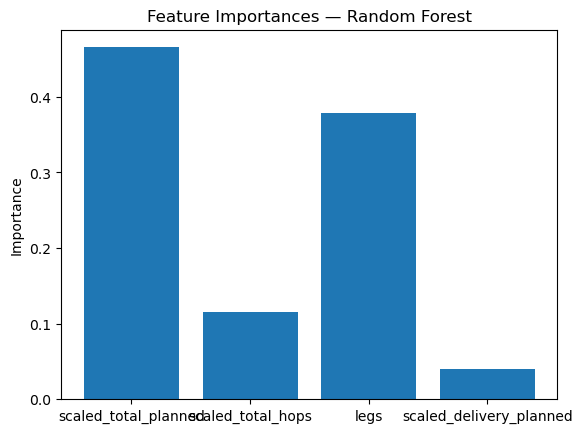

scaled_total_planned         : 0.4657
scaled_total_hops            : 0.1149
legs                         : 0.3791
scaled_delivery_planned      : 0.0402


In [29]:
rf = Pipeline([("prep", preprocess), ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse = mean_squared_error(y_test, pred_rf, squared=False)
mae  = mean_absolute_error(y_test, pred_rf)
r2   = r2_score(y_test, pred_rf)
print(f"Random Forest — RMSE: {rmse:,.2f}  MAE: {mae:,.2f}  R2: {r2:.3f})")

# Predicted vs Actual
plt.figure()
plt.scatter(y_test, pred_rf, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Predicted vs Actual — Random Forest")
plt.xlabel("Actual"); plt.ylabel("Predicted"); plt.show()

# Feature Importances
rf_model = rf.named_steps["model"]
feature_names = ["scaled_total_planned","scaled_total_hops","legs","scaled_delivery_planned"]
importances = rf_model.feature_importances_
plt.figure()
plt.bar(feature_names, importances)
plt.title("Feature Importances — Random Forest"); plt.ylabel("Importance"); plt.show()

for n, imp in zip(feature_names, importances):
    print(f"{n:28s} : {imp:.4f}")


# Evaluation Summary

In [30]:
# Baseline: predict delivery_effective ≈ delivery_planned
baseline = X_test["delivery_planned"].values
def report(name, yhat):
    rmse = mean_squared_error(y_test, yhat, squared=False)
    mae  = mean_absolute_error(y_test, yhat)
    r2   = r2_score(y_test, yhat)
    print(f"{name:36s} RMSE={rmse:,.2f}  MAE={mae:,.2f}  R2={r2:.3f}")

print(f"{'Baseline (y = delivery_planned)':36s} RMSE={mean_squared_error(y_test, baseline, squared=False):,.2f}  MAE={mean_absolute_error(y_test, baseline):,.2f}  R2={r2_score(y_test, baseline):.3f}")
report("Linear Regression", pred_lin)
report("Linear Regression (log1p target)", pred_ll)
report("Random Forest", pred_rf)


Baseline (y = delivery_planned)      RMSE=8,252.03  MAE=7,026.80  R2=-1.176
Linear Regression                    RMSE=5,331.34  MAE=4,243.71  R2=0.092
Linear Regression (log1p target)     RMSE=5,712.14  MAE=3,949.63  R2=-0.043
Random Forest                        RMSE=5,747.59  MAE=4,488.96  R2=-0.056


c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\amitd\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the 

# Application on a New Dataset Without Segmentation

# Using Linear Regression for Prediction of the New Dataset

In [31]:
new_X = df_iqr[["total_planned","legs","total_hops","delivery_planned"]].head(5).copy()
print("New Samples:"); print(new_X)

best_model = rf  # choose the best observed model (change if your output shows another winner)
pred_new = best_model.predict(new_X)
print("\nPredicted delivery_effective (minutes):")
print(pd.Series(pred_new, index=new_X.index))

# Save cleaned feature table
out = df_iqr.copy()
out_cols = ["total_planned","total_effective","total_gap","delivery_planned","delivery_effective","delivery_delay","total_hops","legs"]
out[out_cols].to_csv("cargo_freight_features_IQR_clean.csv", index=False)
print("\nSaved cleaned features to cargo_freight_features_IQR_clean.csv")


New Samples:
   total_planned  legs  total_hops  delivery_planned
0        22793.0     2         3.0            4380.0
1        27058.0     2         4.0           14670.0
2        12578.0     1         2.0            4330.0
3        12902.0     1         3.0            4115.0
4        13284.0     1         4.0            8370.0

Predicted delivery_effective (minutes):
0     3591.589167
1    11642.460417
2     3788.919583
3     3894.710833
4     4853.388750
dtype: float64

Saved cleaned features to cargo_freight_features_IQR_clean.csv
